In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/taseermehboob9/salary-dataset-of-business-levels/salary.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/taseermehboob9/salary-dataset-of-business-levels/salary.csv")
print(df.head(10))
print(df.columns)

            Position  Level    Salary
0   Business Analyst       1    45000
1  Junior Consultant       2    50000
2  Senior Consultant       3    60000
3            Manager       4    80000
4     Country Manger       5   110000
5     Region Manager       6   150000
6            Partner       7   200000
7     Senior Partner       8   220000
8            C.level       9   250000
9                CEO      10  1000000
Index(['Position', 'Level ', 'Salary'], dtype='object')


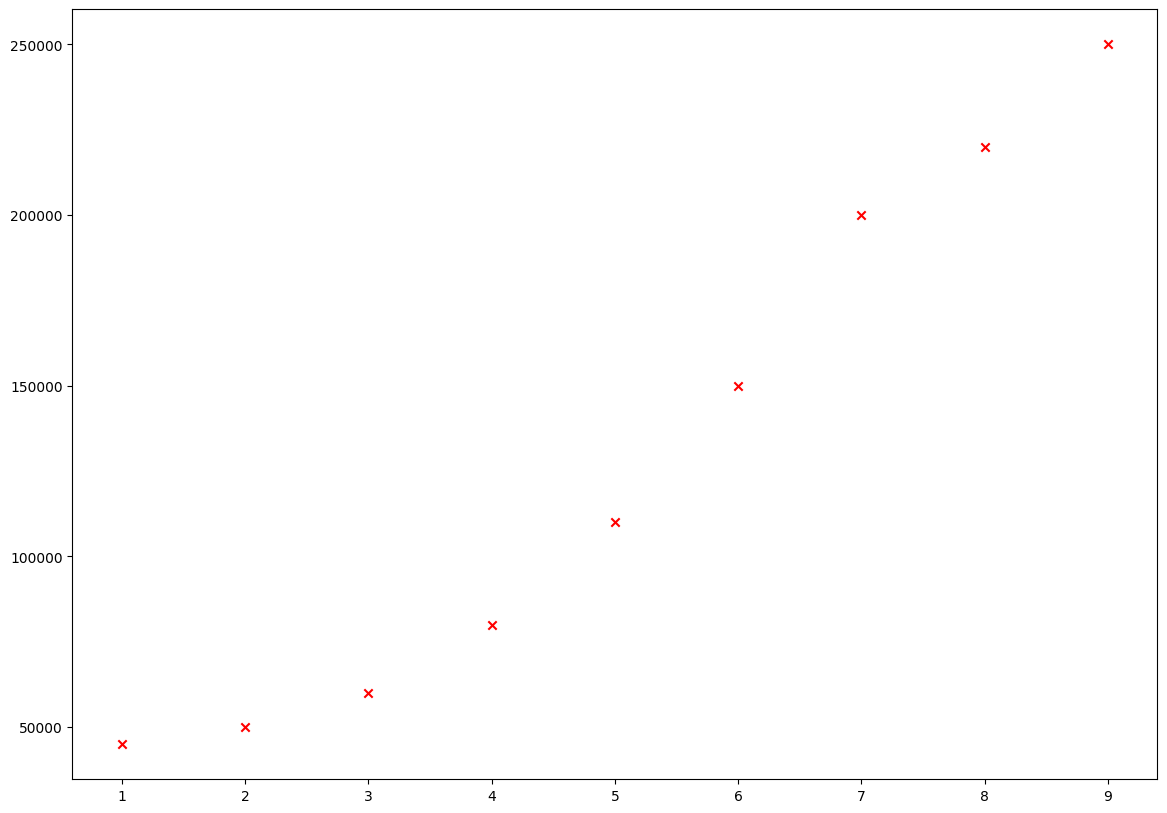

In [3]:
x = df['Level '].values
y = df['Salary'].values
x = x[:-1]
y = y[:-1]
plt.figure(figsize = (14,10))
plt.scatter(x, y, marker='x', label='Training Data',color = "red")

In [4]:
x1 = x
x2 = []
x3 = []

for val in x:
    x2.append(val**2)
    x3.append(val**3)


def normalize(arr):
    mean = sum(arr)/len(arr)
    std = (sum((a-mean)**2 for a in arr)/len(arr))**0.5
    return [(a-mean)/std for a in arr], mean, std


x1, m1, s1 = normalize(x1)
x2, m2, s2 = normalize(x2)
x3, m3, s3 = normalize(x3)


def compute_cost(x1,x2,x3,y,w1,w2,w3,b):
    m = len(x1)
    cost = 0

    for i in range(m):
        y_pred = w1*x1[i]+w2*x2[i]+w3*x3[i]+b
        cost += (y_pred - y[i])**2

    cost = cost/(2*m)
    return cost


def compute_differential(x1,x2,x3,w1,w2,w3,y,b):
    dj_dw1 = 0
    dj_dw2 = 0
    dj_dw3 = 0
    dj_db = 0

    m = len(x1)

    for i in range(m):
        y_pred = w1*x1[i]+w2*x2[i]+w3*x3[i]+b
        dj_dw1 += (y_pred-y[i])*x1[i]
        dj_dw2 += (y_pred-y[i])*x2[i]
        dj_dw3 += (y_pred-y[i])*x3[i]
        dj_db += (y_pred-y[i])

    dj_dw1/=m
    dj_dw2/=m
    dj_dw3/=m
    dj_db/=m

    return dj_dw1,dj_dw2,dj_dw3,dj_db


def gradient_descent(x1,x2,x3,w1,w2,w3,y,b,alpha,epochs):
    cost_history = []

    for i in range(1,epochs+1):
        dj_dw1, dj_dw2, dj_dw3, dj_db = compute_differential(x1, x2, x3, w1, w2, w3, y, b)

        w1 -= alpha*dj_dw1
        w2 -= alpha*dj_dw2
        w3 -= alpha*dj_dw3
        b  -= alpha*dj_db

        if i % 10 == 0:
            cost_history.append(compute_cost(x1,x2,x3,y,w1,w2,w3,b))

        if i % 100000 == 0:
            print(i, w1, w2, w3, b)

    return w1,w2,w3,b,cost_history


y_norm, m_y, s_y = normalize(y)

w1 = w2 = w3 = b = 0.0

w1,w2,w3,b,cost_history = gradient_descent(
    x1,x2,x3,
    w1,w2,w3,
    y_norm,
    b,
    5e-3,
    1000000
)

print(w1, w2, w3, b)

def predict(x_val, w1, w2, w3, b, m1, s1, m2, s2, m3, s3):
    x1 = (x_val - m1) / (s1 + 1e-8)
    x2 = ((x_val**2) - m2) / (s2 + 1e-8)
    x3 = ((x_val**3) - m3) / (s3 + 1e-8)

    return w1*x1 + w2*x2 + w3*x3 + b


print(predict(5, w1, w2, w3, b, m1, s1, m2, s2, m3, s3)*s_y + m_y)

100000 0.004379845037747444 1.3997199872214139 -0.4206362966673695 1.6761283718992958e-16
200000 -0.32457471736853755 2.1798498680867437 -0.8853131317908942 2.8026963466092563e-16
300000 -0.5631693357088912 2.7456872585743577 -1.222348712987567 3.3334446314370186e-16
400000 -0.7362248224136891 3.1560957819842352 -1.4668045894299446 3.3386873512755385e-16
500000 -0.8617440050631281 3.4537699175558205 -1.6441113156664873 3.3467056286755457e-16
600000 -0.9527845465274818 3.6696764739111067 -1.7727139724168093 3.597276797427666e-16
700000 -1.0188173234717859 3.8262760420518926 -1.8659909939618038 3.861879951630082e-16
800000 -1.0667116742834248 3.9398595531589953 -1.933645916248493 3.888401946107224e-16
900000 -1.1014500109976841 4.022243011482587 -1.9827168281816079 3.8985789904995467e-16
1000000 -1.126646135743617 4.0819967040671505 -2.018308538534179 3.8891729343186833e-16
-1.126646135743617 4.0819967040671505 -2.018308538534179 3.8891729343186833e-16
115357.57822362575


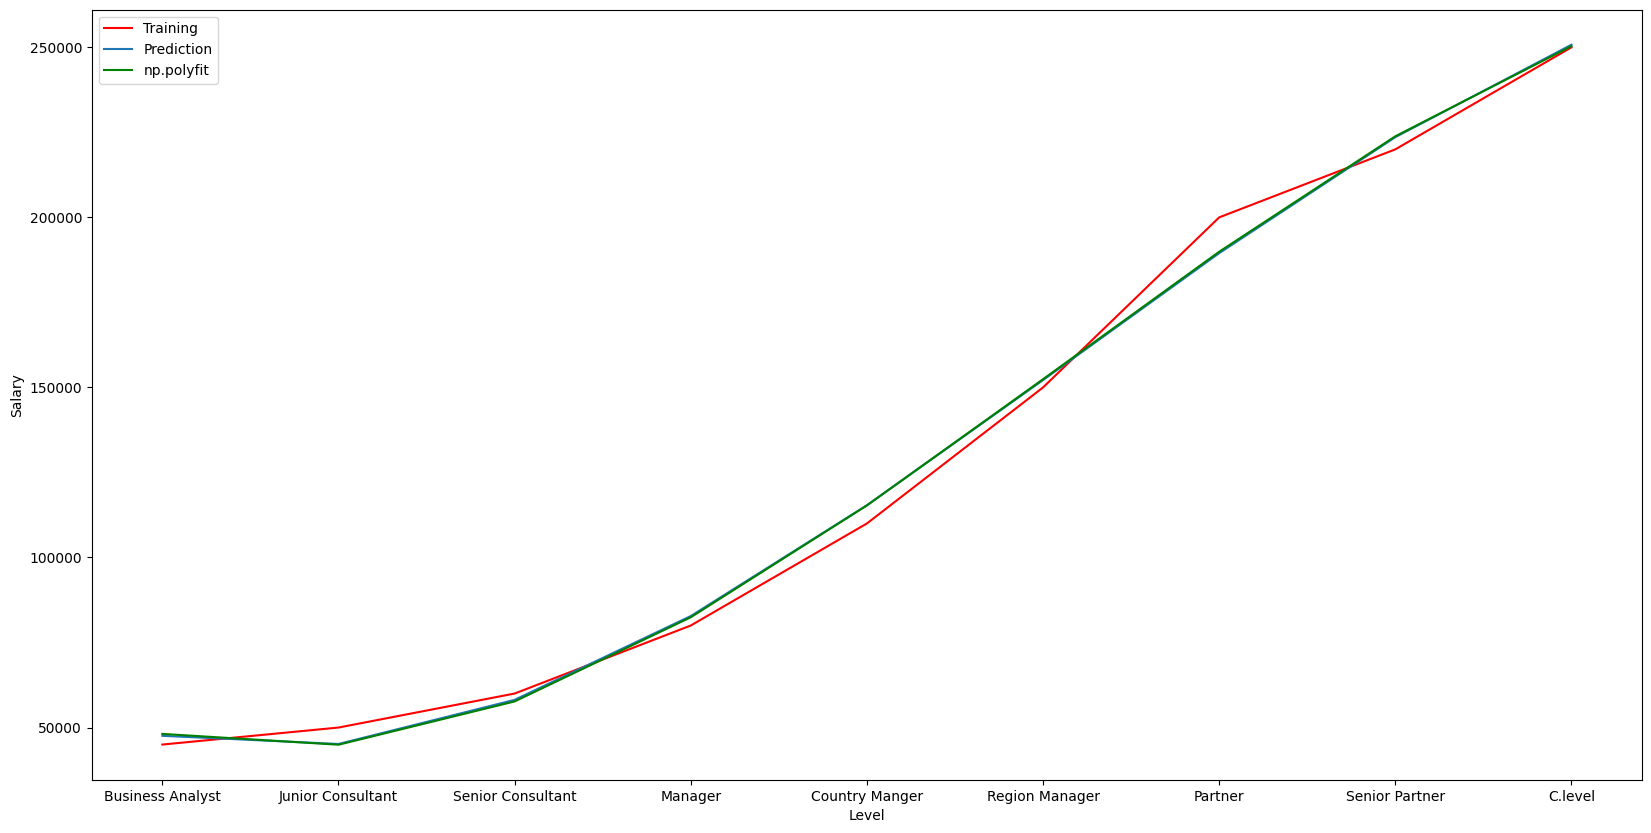

In [5]:
y_pred = []
for i in range(len(x1)):
    y_pred.append((w1*x1[i] + w2*x2[i] + w3*x3[i] + b)*s_y + m_y)


coeffs = np.polyfit(x, y, deg=3)
p = np.poly1d(coeffs)

y_poly = [p(val) for val in x]

plt.figure(figsize=(20,10))

plt.plot(df['Position'][:-1], y, label="Training", color="red")
plt.plot(df['Position'][:-1], y_pred, label="Prediction")
plt.plot(df['Position'][:-1], y_poly, label="np.polyfit", color="green", linestyle="-")

plt.legend()
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()


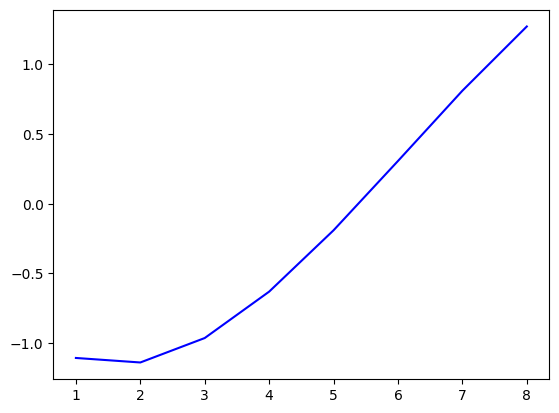

In [6]:
x_range = [i for i in range(int(min(x)), int(max(x)))]

y_pred = [
    predict(val, w1, w2, w3, b, m1, s1, m2, s2, m3, s3)
    for val in x_range
]

plt.plot(x_range, y_pred, color="blue")

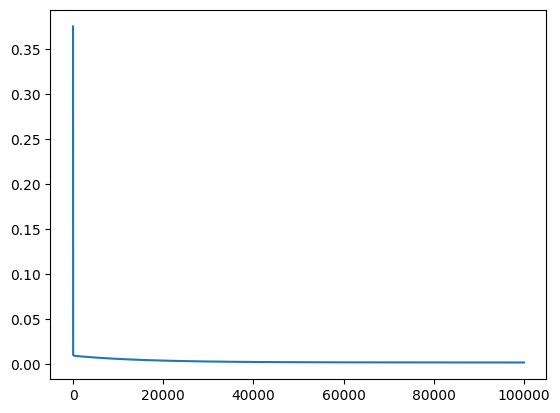

In [7]:
plt.plot(cost_history)